<div align="center">
    <img src="https://compu-flair.com/static/images/CompuFlairLogo.png" width="200">
</div>  

### 🔗  Starting Your Colab Session
1. Open the Google Meet chat.  
2. Copy the `party_time` link shared there.  
3. Paste it in the address bar of the **right-side browser window**.  
4. Hit **Enter** to start your notebook session.

<div align="center">
    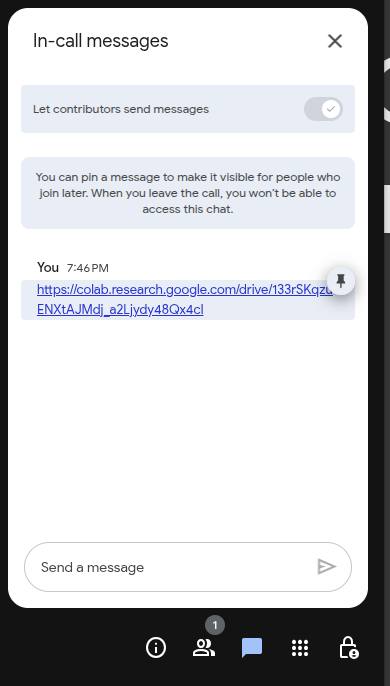
    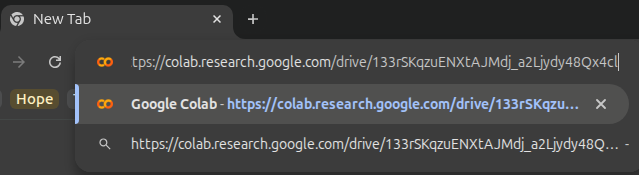
</div>

### 🖥️ Side-by-Side Setup
<div align="center">
    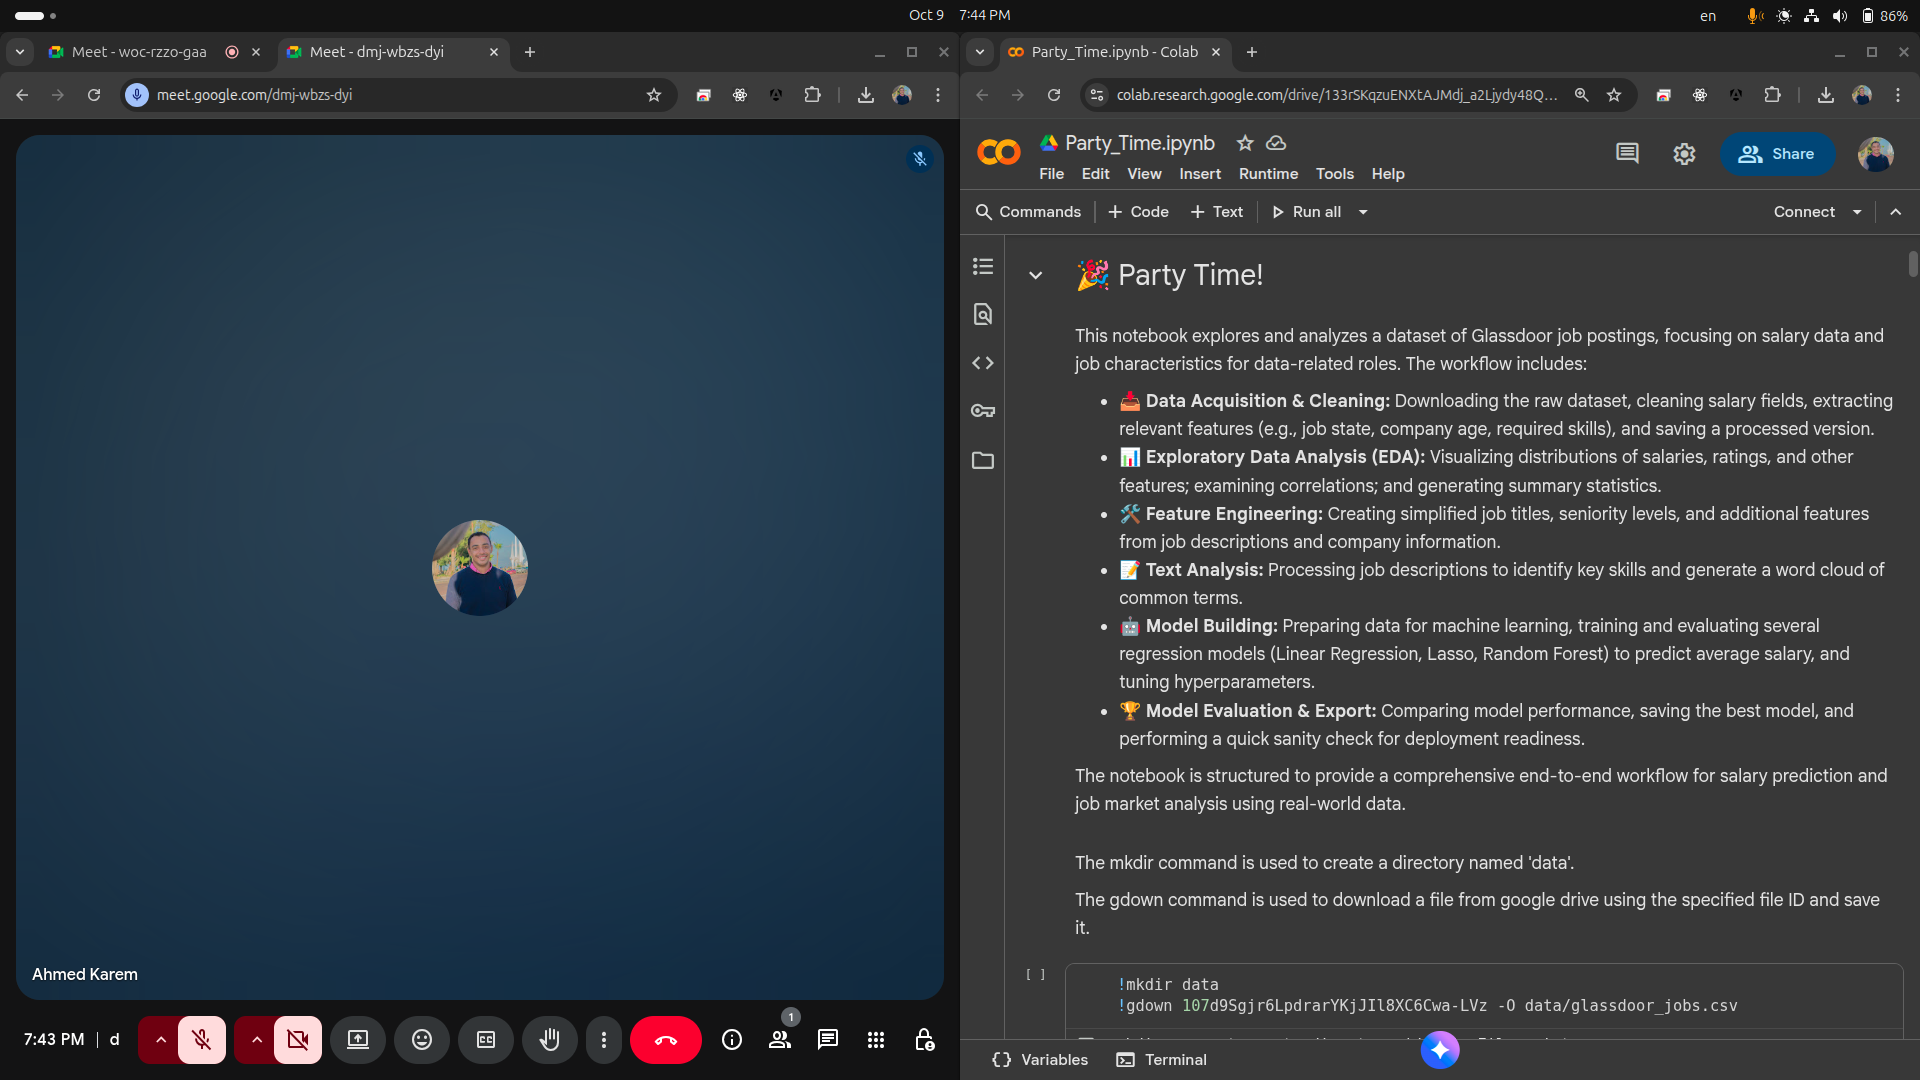
    <
</div>

Make sure your screen looks like this before continuing —  
**Left:** Google Meet (to watch the session)  
**Right:** Colab (to follow along)

### ✅ Quick Check: Is Your Setup Ready?

Have you arranged your screen side-by-side correctly?

- [ ] Yes! Google Meet on the left and Colab on the right.
- [ ] Not yet — I’m still setting it up.

> 📝 *Your response is anonymous — no one will see your name.*

## 🧠 Project Overview

**Problem:** Forecasting the daily BTC/USDT closing price using recent daily candlestick data (Date, Open, High, Low, Close).

**Goal:** Build, tune, and compare ensemble regressors to minimize test error and produce a reliable next‑day closing price forecast.

**Approach:** Fetch Binance daily data via API. Then tune RandomForest, AdaBoost, and XGBoost with GridSearchCV; construct Stacking (Ridge meta‑model) and Voting ensembles, then compute MAPE per model.

## Ensemble learning diagrams

We will first visualizes common ensemble strategies with clean diagrams using NetworkX and Matplotlib.



## Bagging and Boosting

### Bagging (Bootstrap Aggregating)

**What it is:**  
Train many base learners independently on bootstrap-resampled datasets; combine by averaging (regression) or majority vote (classification).

**Why it works:**  
Primarily reduces variance by stabilizing high-variance, unstable learners (each model sees a slightly different sample).

**Typical base learners:**  
- Decision Trees (Random Forest = bagging + feature subsampling)
- Sometimes KNN or others

**Pros:**  
- Simple, parallelizable
- Robust to noisy features
- Reduces overfitting vs a single high-variance model

**Cons:**  
- Does not reduce bias much
- Limited gains if base learner is already low-variance/high-bias

**When to use bagging:**  
- Base model is unstable/high-variance (e.g., deep decision trees)
- Need a strong, low-tuning baseline that is easy to parallelize
- Many features, expect noise/correlation; robustness is desired
- Prioritize stability and interpretability of variable importance (e.g., Random Forest)

---

### Boosting

**What it is:**  
Train weak learners sequentially; each new learner focuses on the residuals/errors of the current ensemble; combine via a weighted sum.

**Why it works:**  
Gradually reduces bias (and, with regularization, can also control variance) by fitting remaining structure in the data.

**Typical algorithms:**  
- AdaBoost
- Gradient Boosting (GBDT)
- XGBoost
- LightGBM
- CatBoost

**Pros:**  
- Often state-of-the-art on tabular data
- Flexible losses
- Strong accuracy with proper tuning

**Cons:**  
- More sensitive to noise/outliers
- More hyperparameters
- Higher risk of overfitting without regularization
- Less parallel than bagging

**When to use boosting:**  
- Current model underfits (high bias) and you want to push accuracy
- Data is reasonably clean or you can mitigate outliers (robust losses, early stopping, subsampling)
- Can invest in tuning/regularization (learning rate, number of trees, tree depth, subsampling/colsample, L1/L2, min child weight/leaves)
- Goal: maximize performance on tabular problems with careful control of overfitting

---

**Rule of thumb:**  
- Prefer **bagging** for variance reduction, stability, and minimal tuning  
- Prefer **boosting** for best possible accuracy and when you can tune/regularize to manage overfitting

### Bagging (basic)
- Sets a plotting theme and defines helper functions
- Renders the Bagging (bootstrap aggregating) workflow next using networkx and matplotlib

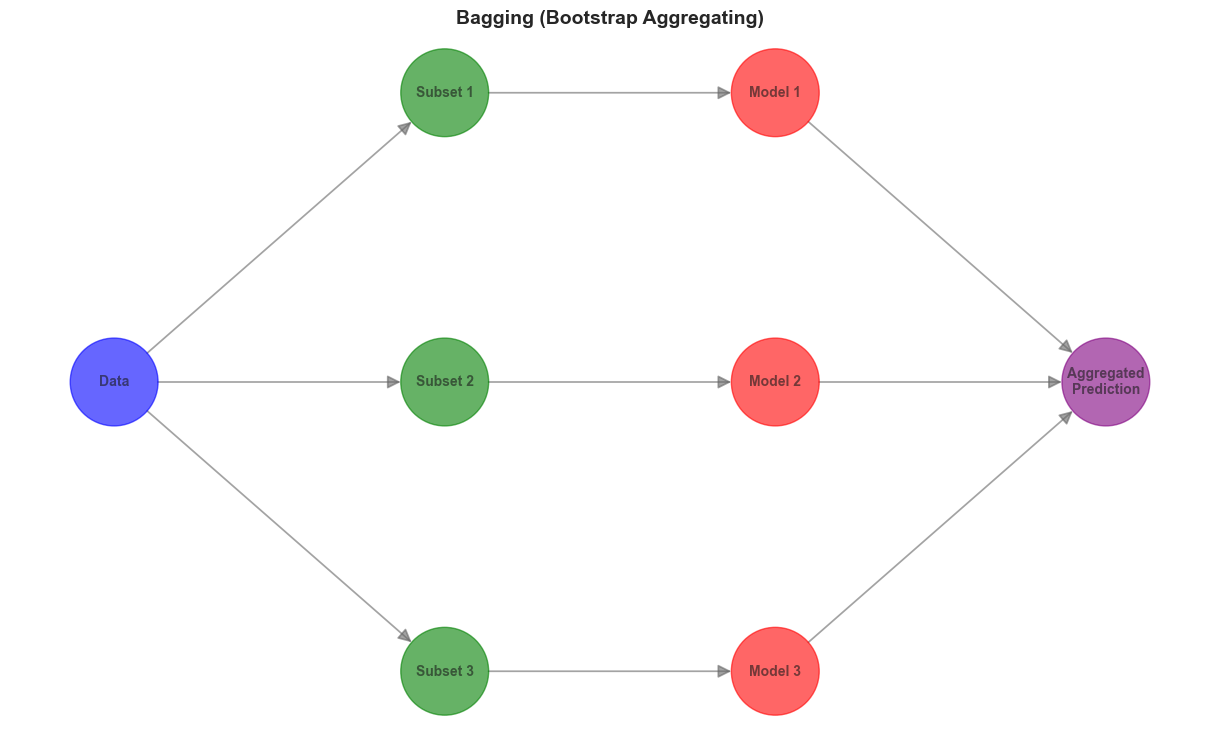

In [26]:
import numpy as np  # Import NumPy for numerical operations
import matplotlib.pyplot as plt  # Import Matplotlib for plotting
import seaborn as sns  # Import Seaborn for plot styling
import networkx as nx  # Import NetworkX for graph creation

# Setting a theme and style for plots
sns.set_theme(style="whitegrid")  # Set Seaborn theme to whitegrid
plt.rcParams["axes.edgecolor"] = "0.15"  # Set edge color for axes
plt.rcParams["axes.linewidth"] = 1.25  # Set linewidth for axes


def plot_bagging():
    G = nx.DiGraph()  # Create a directed graph

    G.add_node(
        "Data", pos=(1, 3), color="blue"
    )  # Add 'Data' node with position and color
    for i, label in enumerate(
        ["Subset 1", "Subset 2", "Subset 3"]
    ):  # Loop over subsets
        G.add_node(label, pos=(2, 5 - i * 2), color="green")  # Add subset node
        G.add_edge("Data", label)  # Connect 'Data' to subset

        G.add_node(f"Model {i+1}", pos=(3, 5 - i * 2), color="red")  # Add model node
        G.add_edge(label, f"Model {i+1}")  # Connect subset to model

    G.add_node(
        "Aggregated\nPrediction", pos=(4, 3), color="purple"
    )  # Add aggregated prediction node
    for i in range(3):  # Loop over models
        G.add_edge(
            f"Model {i+1}", "Aggregated\nPrediction"
        )  # Connect model to aggregated prediction

    pos = nx.get_node_attributes(G, "pos")  # Get node positions
    color = [G.nodes[node]["color"] for node in G.nodes]  # Get node colors

    plt.figure(figsize=(12, 7))  # Create a new figure
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=4000,
        node_color=color,
        font_size=10,
        font_weight="bold",
        edge_color="0.4",
        width=1.25,
        alpha=0.6,
        arrowsize=20,
    )  # Draw the graph

    plt.title(
        "Bagging (Bootstrap Aggregating)", fontsize=14, fontweight="bold"
    )  # Set plot title
    plt.show()  # Show the plot


def plot_boosting():
    G = nx.DiGraph()  # Create a directed graph

    prev_model = None  # Initialize previous model variable
    for i in range(4):  # Loop over 4 models
        current_model = f"Model {i+1}"  # Define current model name
        G.add_node(current_model, pos=(i + 1, 3), color="red")  # Add model node

        if prev_model:  # If previous model exists
            G.add_edge(prev_model, current_model)  # Connect previous to current model
        prev_model = current_model  # Update previous model

    pos = nx.get_node_attributes(G, "pos")  # Get node positions
    color = [G.nodes[node]["color"] for node in G.nodes]  # Get node colors

    plt.figure(figsize=(12, 7))  # Create a new figure
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=4000,
        node_color=color,
        font_size=10,
        font_weight="bold",
        edge_color="0.4",
        width=1.25,
        alpha=0.6,
        arrowsize=20,
    )  # Draw the graph

    plt.title(
        "Boosting: Sequential Model Training", fontsize=14, fontweight="bold"
    )  # Set plot title
    plt.show()  # Show the plot


# Execute the plotting functions
plot_bagging()  # Call the bagging plot function

As we see from previous plot, bagging builds multiple independent models in parallel on different bootstrap samples of the data, then aggregates their predictions to reduce variance.

### Boosting (basic)

Calls `plot_boosting()` to render the sequential boosting pipeline where each model builds on the previous one.

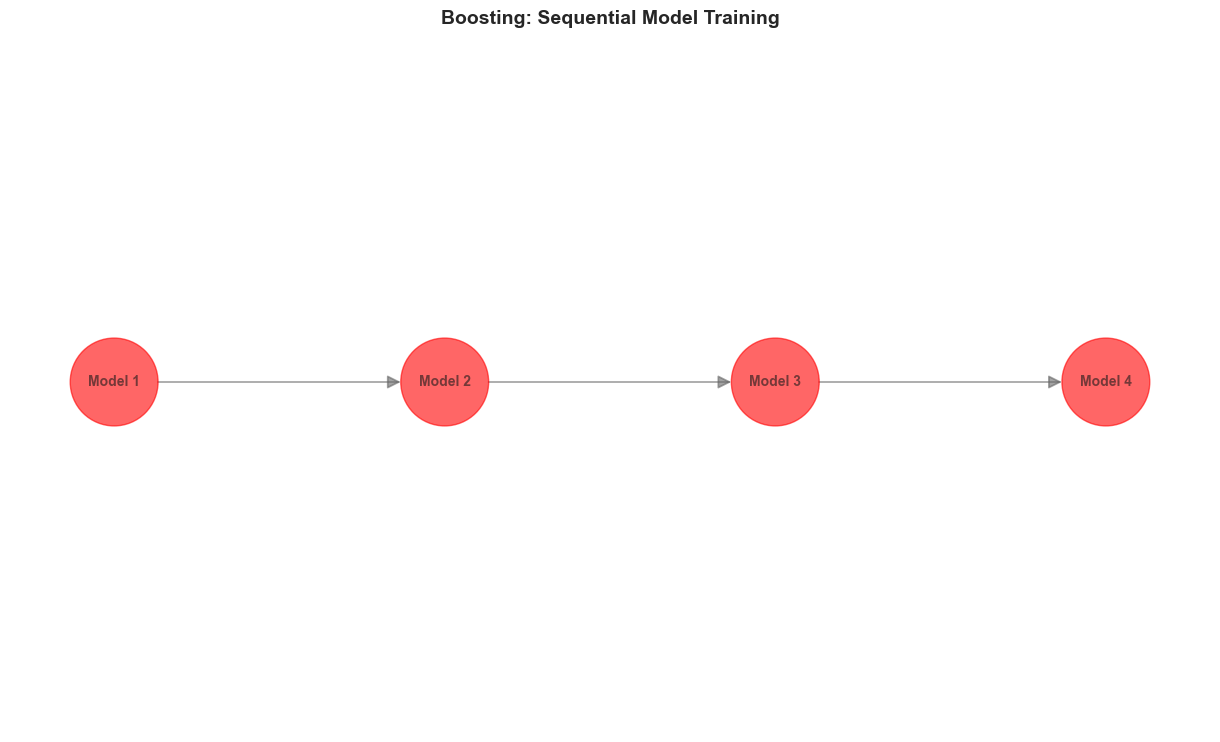

In [2]:
plot_boosting()  # Call the function to plot the boosting process diagram

As we see from previous plot, boosting builds models sequentially, where each new model focuses on correcting the errors of the combined previous models, thereby reducing bias.

### Bagging & Boosting (enhanced styling)

Re-implements the diagrams with improved colors, square node shapes, and higher contrast; then renders both.

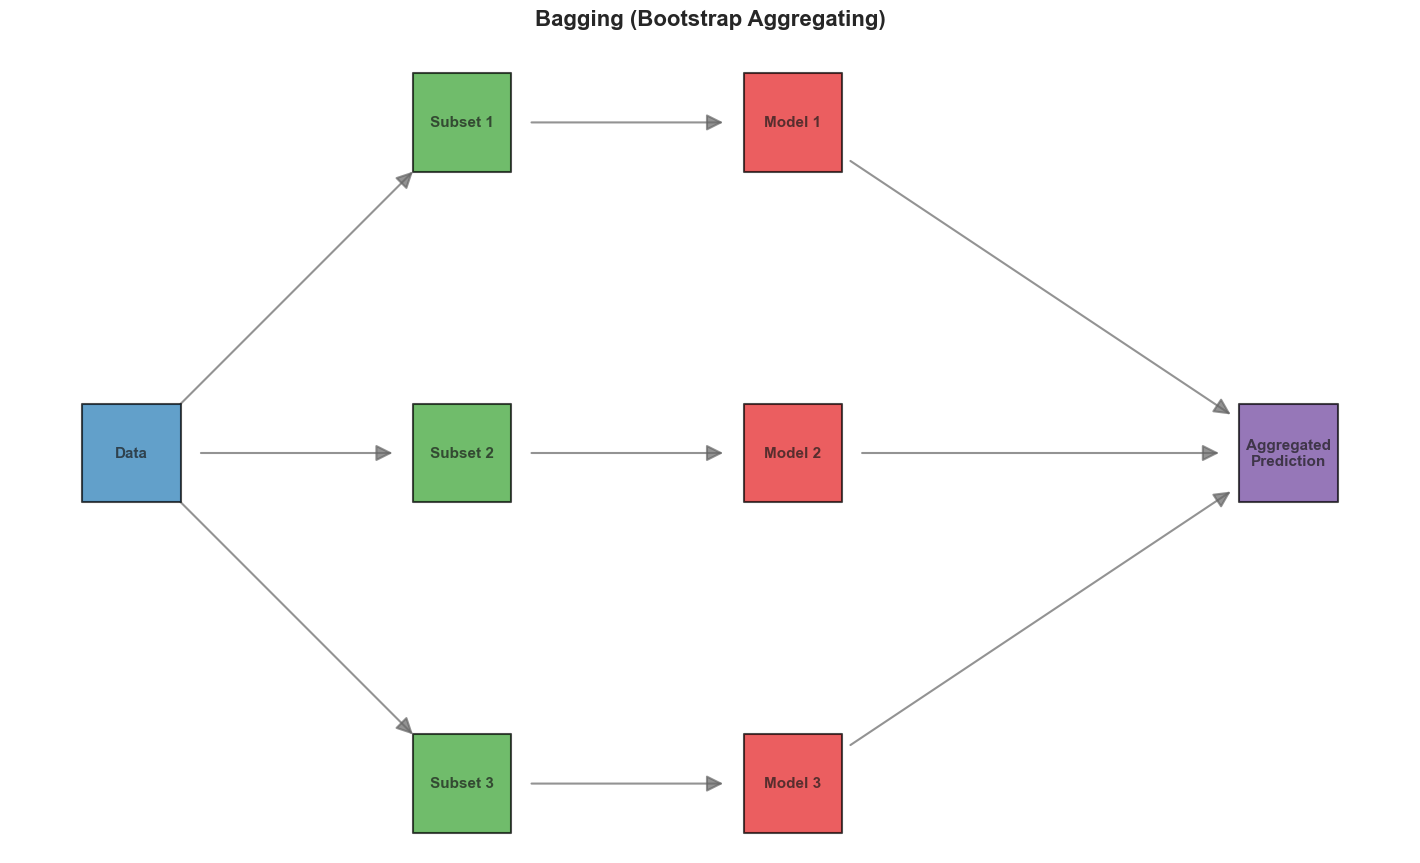

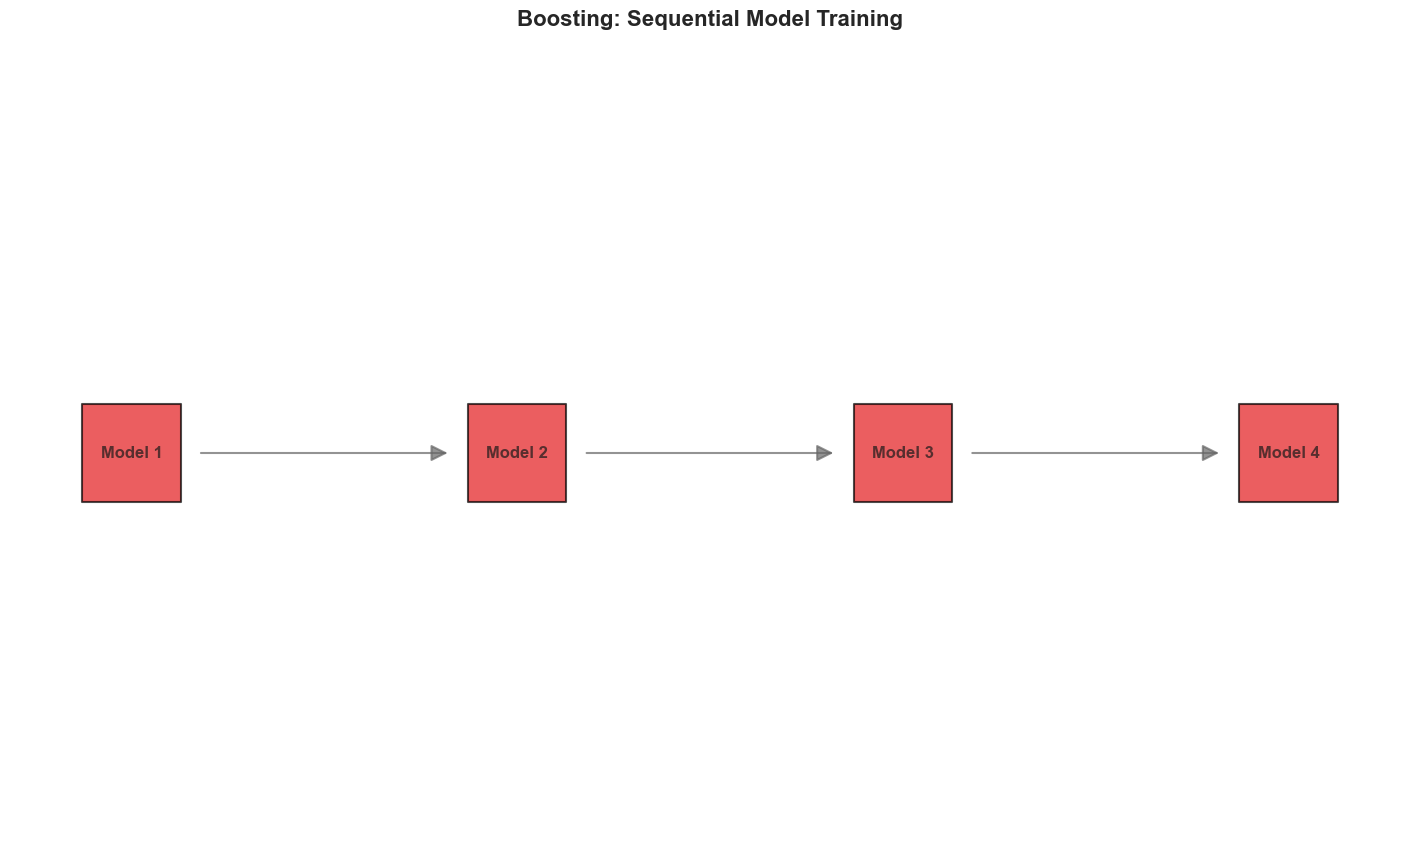

In [3]:
import numpy as np  # Import NumPy for numerical operations
import matplotlib.pyplot as plt  # Import Matplotlib for plotting
import seaborn as sns  # Import Seaborn for plot styling
import networkx as nx  # Import NetworkX for graph creation

# Styling
sns.set_style("whitegrid")  # Set Seaborn style to whitegrid
plt.rcParams["axes.edgecolor"] = "0.5"  # Set edge color for axes
plt.rcParams["axes.linewidth"] = 1.5  # Set linewidth for axes


def plot_bagging():
    G = nx.DiGraph()  # Create a directed graph

    G.add_node(
        "Data", pos=(1, 3), color="#1f78b4"
    )  # Add 'Data' node with position and color
    for i, label in enumerate(
        ["Subset 1", "Subset 2", "Subset 3"]
    ):  # Loop over subsets
        G.add_node(
            label, pos=(2, 5 - i * 2), color="#33a02c"
        )  # Add subset node with position and color
        G.add_edge("Data", label)  # Connect 'Data' to subset

        G.add_node(
            f"Model {i+1}", pos=(3, 5 - i * 2), color="#e31a1c"
        )  # Add model node with position and color
        G.add_edge(label, f"Model {i+1}")  # Connect subset to model

    G.add_node(
        "Aggregated\nPrediction", pos=(4.5, 3), color="#6a3d9a"
    )  # Add aggregated prediction node
    for i in range(3):  # Loop over models
        G.add_edge(
            f"Model {i+1}", "Aggregated\nPrediction"
        )  # Connect model to aggregated prediction

    pos = nx.get_node_attributes(G, "pos")  # Get node positions
    color = [G.nodes[node]["color"] for node in G.nodes]  # Get node colors

    plt.figure(figsize=(14, 8))  # Create a new figure
    nx.draw(
        G,
        pos,
        with_labels=True,  # Show node labels
        node_size=5000,  # Set node size
        node_color=color,  # Set node colors
        font_size=11,  # Set font size for labels
        font_weight="bold",  # Set font weight for labels
        edge_color="0.4",  # Set edge color
        width=1.5,  # Set edge width
        alpha=0.7,  # Set transparency
        arrowsize=25,  # Set arrow size
        node_shape="s",  # Set node shape to square
        edgecolors="#000000",  # Set edge color for nodes
        linewidths=1.5,  # Set node edge linewidth
    )

    plt.title(
        "Bagging (Bootstrap Aggregating)", fontsize=16, fontweight="bold", pad=20
    )  # Set plot title
    plt.show()  # Show the plot


def plot_boosting():
    G = nx.DiGraph()  # Create a directed graph

    prev_model = None  # Initialize previous model variable
    for i in range(4):  # Loop over 4 models
        current_model = f"Model {i+1}"  # Define current model name
        G.add_node(
            current_model, pos=(i * 1.5 + 1, 3), color="#e31a1c"
        )  # Add model node with position and color

        if prev_model:  # If previous model exists
            G.add_edge(prev_model, current_model)  # Connect previous to current model
        prev_model = current_model  # Update previous model

    pos = nx.get_node_attributes(G, "pos")  # Get node positions
    color = [G.nodes[node]["color"] for node in G.nodes]  # Get node colors

    plt.figure(figsize=(14, 8))  # Create a new figure
    nx.draw(
        G,
        pos,
        with_labels=True,  # Show node labels
        node_size=5000,  # Set node size
        node_color=color,  # Set node colors
        font_size=12,  # Set font size for labels
        font_weight="bold",  # Set font weight for labels
        edge_color="0.4",  # Set edge color
        width=1.5,  # Set edge width
        alpha=0.7,  # Set transparency
        arrowsize=25,  # Set arrow size
        node_shape="s",  # Set node shape to square
        edgecolors="#000000",  # Set edge color for nodes
        linewidths=1.5,  # Set node edge linewidth
    )

    plt.title(
        "Boosting: Sequential Model Training", fontsize=16, fontweight="bold", pad=20
    )  # Set plot title
    plt.show()  # Show the plot


# Execute the plotting functions
plot_bagging()  # Call the bagging plot function
plot_boosting()  # Call the boosting plot function

### Stacking

Defines `plot_stacking()` showing base models → predictions → meta-model → final prediction; then renders the diagram.

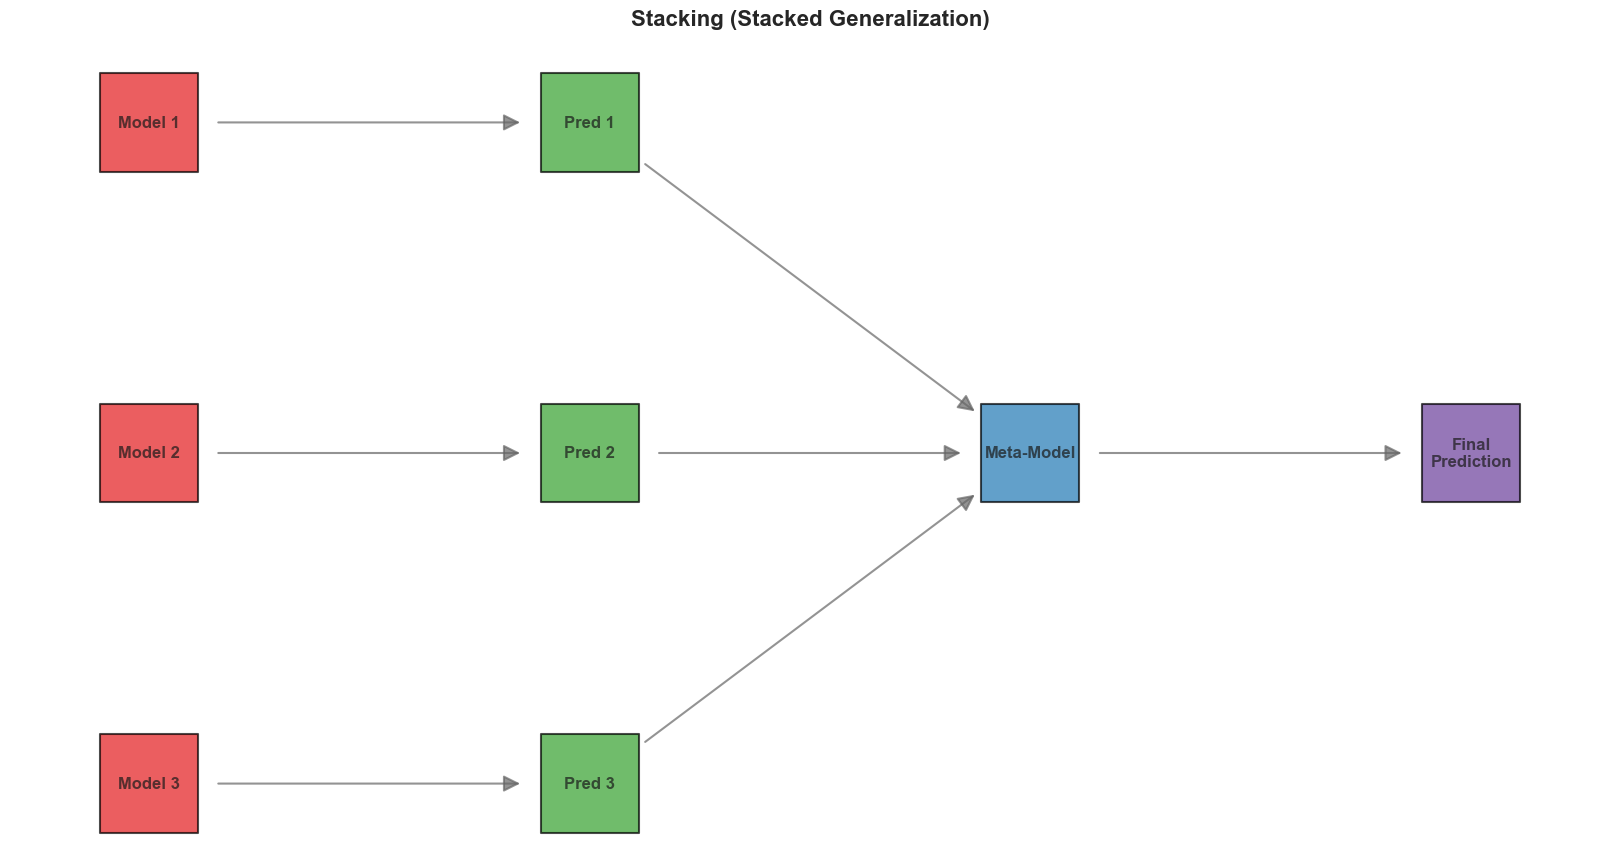

In [4]:
import numpy as np  # Import NumPy for numerical operations
import matplotlib.pyplot as plt  # Import Matplotlib for plotting
import seaborn as sns  # Import Seaborn for plot styling
import networkx as nx  # Import NetworkX for graph creation

# Styling
sns.set_style("whitegrid")  # Set Seaborn style to whitegrid
plt.rcParams["axes.edgecolor"] = "0.5"  # Set edge color for axes
plt.rcParams["axes.linewidth"] = 1.5  # Set linewidth for axes


def plot_stacking():
    G = nx.DiGraph()  # Create a directed graph

    # Base models
    for i, label in enumerate(
        ["Model 1", "Model 2", "Model 3"]
    ):  # Loop over base models
        G.add_node(
            label, pos=(1, 5 - i * 2), color="#e31a1c"
        )  # Add base model node with position and color

    # Predictions from base models
    for i, label in enumerate(["Pred 1", "Pred 2", "Pred 3"]):  # Loop over predictions
        G.add_node(
            label, pos=(2.5, 5 - i * 2), color="#33a02c"
        )  # Add prediction node with position and color
        G.add_edge(f"Model {i+1}", label)  # Connect base model to its prediction

    # Meta-model making final prediction based on base model predictions
    G.add_node("Meta-Model", pos=(4, 3), color="#1f78b4")  # Add meta-model node
    for i in range(3):  # Loop over predictions
        G.add_edge(f"Pred {i+1}", "Meta-Model")  # Connect prediction to meta-model

    G.add_node(
        "Final\nPrediction", pos=(5.5, 3), color="#6a3d9a"
    )  # Add final prediction node
    G.add_edge(
        "Meta-Model", "Final\nPrediction"
    )  # Connect meta-model to final prediction

    pos = nx.get_node_attributes(G, "pos")  # Get node positions
    color = [G.nodes[node]["color"] for node in G.nodes]  # Get node colors

    plt.figure(figsize=(16, 8))  # Create a new figure
    nx.draw(
        G,
        pos,
        with_labels=True,  # Show node labels
        node_size=5000,  # Set node size
        node_color=color,  # Set node colors
        font_size=12,  # Set font size for labels
        font_weight="bold",  # Set font weight for labels
        edge_color="0.4",  # Set edge color
        width=1.5,  # Set edge width
        alpha=0.7,  # Set transparency
        arrowsize=25,  # Set arrow size
        node_shape="s",  # Set node shape to square
        edgecolors="#000000",  # Set edge color for nodes
        linewidths=1.5,  # Set node edge linewidth
    )

    plt.title(
        "Stacking (Stacked Generalization)", fontsize=16, fontweight="bold", pad=20
    )  # Set plot title
    plt.show()  # Show the plot


# Execute the plotting function
plot_stacking()  # Call the stacking plot function

Notice how stacking uses a meta-model to learn how to best combine base model predictions, while voting simply aggregates them via majority or averaging.

### Voting

Defines `plot_voting()` where three base models feed a voting mechanism; then renders the final decision.

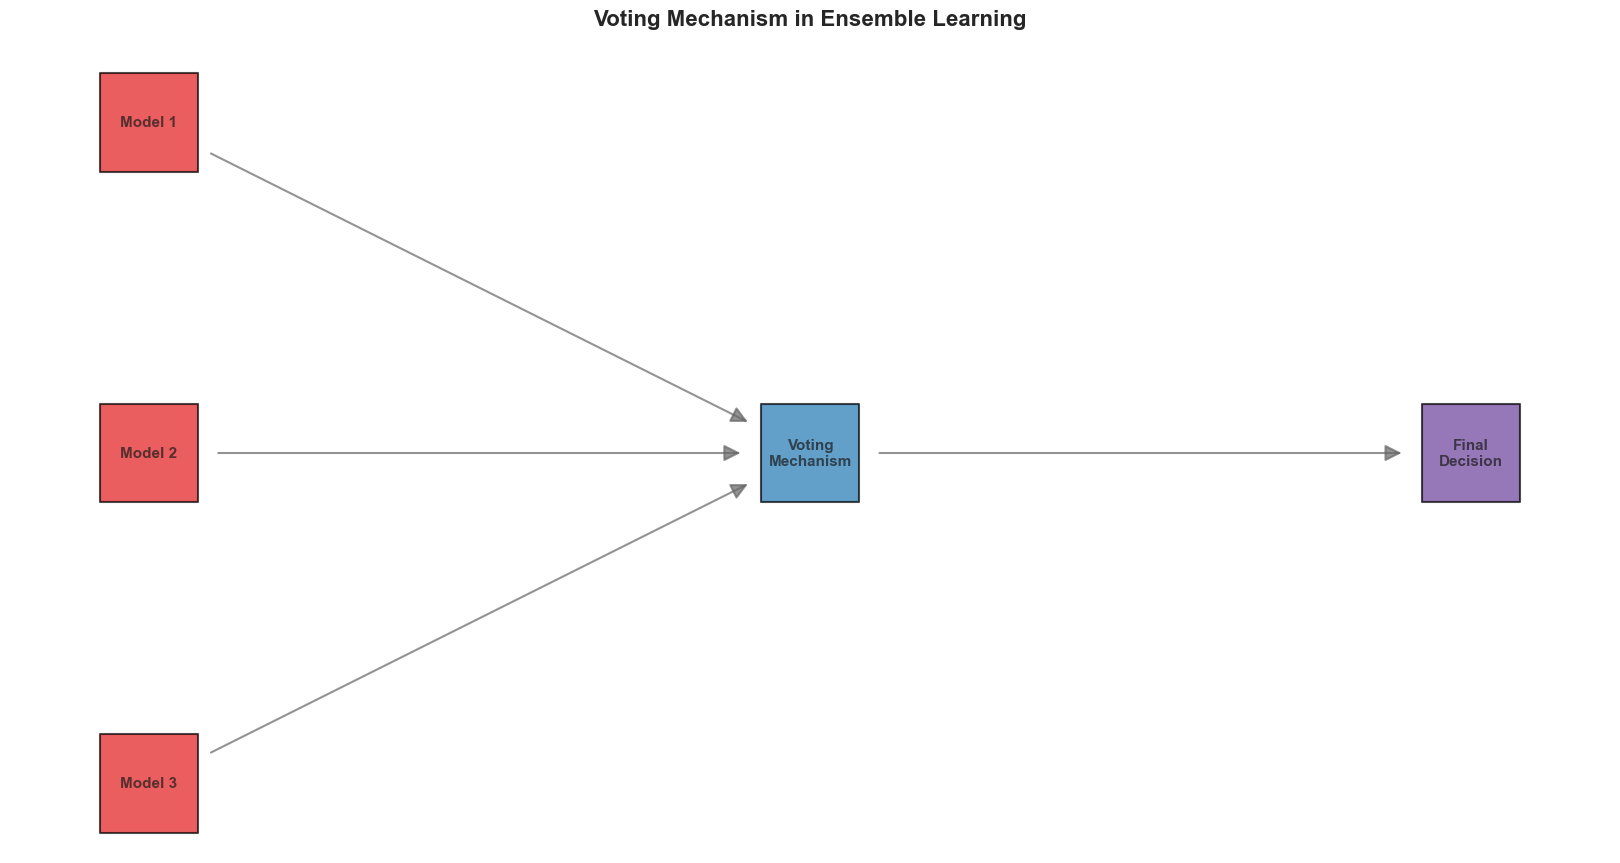

In [5]:
import numpy as np  # Import NumPy for numerical operations
import matplotlib.pyplot as plt  # Import Matplotlib for plotting
import seaborn as sns  # Import Seaborn for plot styling
import networkx as nx  # Import NetworkX for graph creation

# Styling
sns.set_style("whitegrid")  # Set Seaborn style to whitegrid
plt.rcParams["axes.edgecolor"] = "0.5"  # Set edge color for axes
plt.rcParams["axes.linewidth"] = 1.5  # Set linewidth for axes


def plot_voting():
    G = nx.DiGraph()  # Create a directed graph

    # Base models making their predictions
    for i, label in enumerate(
        ["Model 1", "Model 2", "Model 3"]
    ):  # Loop over base models
        G.add_node(
            label, pos=(1, 5 - i * 2), color="#e31a1c"
        )  # Add base model node with position and color

    # Voting mechanism
    G.add_node(
        "Voting\nMechanism", pos=(3, 3), color="#1f78b4"
    )  # Add voting mechanism node
    for i in range(3):  # Loop over base models
        G.add_edge(
            f"Model {i+1}", "Voting\nMechanism"
        )  # Connect each model to voting mechanism

    # Final Decision after Voting
    G.add_node(
        "Final\nDecision", pos=(5, 3), color="#6a3d9a"
    )  # Add final decision node
    G.add_edge(
        "Voting\nMechanism", "Final\nDecision"
    )  # Connect voting mechanism to final decision

    pos = nx.get_node_attributes(G, "pos")  # Get node positions
    color = [G.nodes[node]["color"] for node in G.nodes]  # Get node colors

    plt.figure(figsize=(16, 8))  # Create a new figure
    nx.draw(
        G,
        pos,
        with_labels=True,  # Show node labels
        node_size=5000,  # Set node size
        node_color=color,  # Set node colors
        font_size=11,  # Set font size for labels
        font_weight="bold",  # Set font weight for labels
        edge_color="0.4",  # Set edge color
        width=1.5,  # Set edge width
        alpha=0.7,  # Set transparency
        arrowsize=25,  # Set arrow size
        node_shape="s",  # Set node shape to square
        edgecolors="#000000",  # Set edge color for nodes
        linewidths=1.5,  # Set node edge linewidth
    )

    plt.title(
        "Voting Mechanism in Ensemble Learning", fontsize=16, fontweight="bold", pad=20
    )  # Set plot title
    plt.show()  # Show the plot


# Execute the plotting function
plot_voting()  # Call the voting plot function

Notice how the voting mechanism aggregates predictions from multiple base models to make a final decision, enhancing overall model robustness and accuracy.

## Build Ensemble Models on Bitcoin Data


# Fetch BTC/USDT daily data from Binance
Call the Binance REST API (1d interval starting from year 2025 ) and build a pandas DataFrame with Date, Open, High, Low, and Close columns.

In [6]:
# Import required libraries
import requests  # For making HTTP requests to APIs
import pandas as pd  # For data manipulation and analysis

# Define the Binance API endpoint for daily BTC/USDT candlestick data
key = "https://api.binance.us/api/v3/klines?symbol=BTCUSDT&interval=1d&startTime=1735689600000"

# Send a GET request to the API endpoint
data = requests.get(key)
data = data.json()  # Parse the response as JSON
# Extract relevant price information from the API response
prices = [
    {
        "Date": item[0],  # Timestamp in milliseconds
        "Open": float(item[1]),  # Opening price for the day
        "High": float(item[2]),  # Highest price for the day
        "Low": float(item[3]),  # Lowest price for the day
        "Close": float(item[4]),  # Closing price for the day
    }
    for item in data
]

# Convert the list of price dictionaries into a pandas DataFrame
btc_usdt = pd.DataFrame(prices)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [24]:
#as binance has bloced iran I use Bitstamp or coingecko
import numpy as np
import requests  # For making HTTP requests to APIs
import pandas as pd  # For data manipulation and analysis
url="https://www.bitstamp.net/api/v2/ohlc/btcusd/"
params = {"step": "86400", "limit": "365"}
response=requests.get(url,params)
dat3=response
dat3=response.json()
#data=data["data"]
dat3=pd.DataFrame(dat3['data']['ohlc'])
print(dat3)

      timestamp   open   high    low  close         volume
0    1732233600  98451  99800  97236  99013  4646.09454486
1    1732320000  99010  99015  97226  97775  1719.12474462
2    1732406400  97765  98660  95796  98007  1814.00757210
3    1732492800  98021  98966  92584  93035  2969.54841533
4    1732579200  93006  94999  90742  91928  3575.09743077
..          ...    ...    ...    ...    ...            ...
360  1763337600  94186  95938  91168  92102  4149.83016963
361  1763424000  92112  93753  89189  92911  4742.04243662
362  1763510400  92911  92936  88497  91474  3769.12562257
363  1763596800  91468  93065  85912  86527  5180.91421150
364  1763683200  86511  87386  80537  84802  8010.67637760

[365 rows x 6 columns]


# Inspect the raw data
Show the first few rows of the fetched BTC/USDT dataset to verify schema and sample values.

In [ ]:
# Display the first five rows of the btc_usdt DataFrame to inspect the data structure and sample values
btc_usdt.head()

,Date,Open,High,Low,Close
0,1735689600000,93500.00,95073.76,92990.95,94701.87
1,1735776000000,94650.20,97777.00,94394.34,96856.15
2,1735862400000,96992.78,98897.97,96181.90,98186.71
3,1735948800000,98186.71,98700.00,97556.80,98337.49
4,1736035200000,98325.25,98777.00,97331.67,98300.03


# Train/test split setup
Create features X (all columns except Close) and target y (Close), then split into train/test without shuffling to preserve time order.

In [ ]:
# Import the train_test_split function from scikit-learn for splitting data
from sklearn.model_selection import train_test_split

# Splitting the dataset
# Drop the 'Close' column from btc_usdt to create features (X)
# The 'Close' column is the target variable we want to predict
X = btc_usdt.drop("Close", axis=1)

# Extract the 'Close' column as the target variable (y)
# This is what our models will try to predict
y = btc_usdt["Close"]

# Split the data into training and testing sets
# X_train, y_train will be used to train the models
# X_test, y_test will be used to evaluate model performance
# test_size=0.2 means 20% of data goes to testing, 80% to training
# shuffle=False preserves the time-series order of the data (important for time series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Random Forest tuning (GridSearchCV)
Run a parameter grid over RandomForestRegressor with 3-fold CV, fit on training data, and keep the best estimator.

In [ ]:
# Import GridSearchCV for hyperparameter tuning using cross-validation
# GridSearchCV systematically works through multiple combinations of parameter tunes,
# cross-validating as it goes to determine which tune gives the best performance
from sklearn.model_selection import GridSearchCV

# Import RandomForestRegressor - an ensemble learning method that operates by
# constructing multiple decision trees during training and outputting the mean prediction
from sklearn.ensemble import RandomForestRegressor

# Define the hyperparameter grid for Random Forest
# This dictionary contains all the parameters we want to test
param_grid_rf = {
    # n_estimators: Number of trees in the forest
    # Testing 50, 100, and 150 trees to find optimal forest size
    "n_estimators": [50, 100, 150],
    # max_features: Number of features to consider when looking for the best split
    # 'log2' uses log2(n_features) features, 'sqrt' uses sqrt(n_features) features
    # These reduce overfitting by limiting feature consideration at each split
    "max_features": ["log2", "sqrt"],
    # max_depth: Maximum depth of each tree
    # Testing depths of 10, 20, 30, and None (nodes expand until all leaves are pure)
    # Deeper trees can capture more complex patterns but may overfit
    "max_depth": [10, 20, 30, None],
    # min_samples_split: Minimum number of samples required to split an internal node
    # Higher values prevent creating nodes with very few samples, reducing overfitting
    "min_samples_split": [2, 5, 10],
    # min_samples_leaf: Minimum number of samples required to be at a leaf node
    # Similar to min_samples_split, this smooths the model and prevents overfitting
    "min_samples_leaf": [1, 2, 4],
}

# Create GridSearchCV object to perform hyperparameter tuning
grid_search_rf = GridSearchCV(
    # Base estimator to tune - RandomForestRegressor with default parameters
    RandomForestRegressor(),
    # Parameter grid defined above - GridSearch will try all combinations
    param_grid_rf,
    # cv=3: Use 3-fold cross-validation
    # Data is split into 3 parts; model trains on 2 parts and validates on 1, rotating through all combinations
    cv=3,
    # n_jobs=-1: Use all available CPU cores for parallel processing
    # Significantly speeds up the grid search process
    n_jobs=-1,
    # verbose=2: Print detailed progress messages
    # Shows which parameter combination is being evaluated and timing information
    verbose=2,
    # scoring='neg_mean_squared_error': Evaluation metric for model performance
    # Negative because sklearn's convention is that higher scores are better
    # MSE measures average squared difference between predicted and actual values
    scoring="neg_mean_squared_error",
)

# Fit the grid search to the training data
# This trains a Random Forest model for each combination of parameters
# X_train contains the features (Date, Open, High, Low)
# y_train contains the target variable (Close price)
grid_search_rf.fit(X_train, y_train)

# Extract the best model from grid search
# best_estimator_ is the model with the parameter combination that achieved the best cross-validation score
# This model is already trained on the full training dataset
best_rf = grid_search_rf.best_estimator_

Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=   0.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   0.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=   0.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=50; 

# AdaBoost tuning (GridSearchCV)
Search over n_estimators and learning_rate with 3-fold CV, fit on training data, and keep the best AdaBoost model.

In [ ]:
# Import AdaBoostRegressor - an ensemble method that combines multiple weak learners
# (typically shallow decision trees) by focusing on previously misclassified samples
# Each subsequent model pays more attention to the errors of previous models
from sklearn.ensemble import AdaBoostRegressor

# Define the hyperparameter grid for AdaBoost
# This dictionary contains all the parameters we want to test through grid search
param_grid_ada = {
    # n_estimators: Number of weak learners (base estimators) to train sequentially
    # Testing 50, 100, and 150 estimators to find the optimal number
    # More estimators can improve performance but increase training time
    "n_estimators": [50, 100, 150],
    # learning_rate: Weight applied to each weak learner's contribution
    # Controls how much each estimator contributes to the final prediction
    # Lower values (0.01, 0.05) make learning more cautious and require more estimators
    # Higher values (0.5, 1) make learning more aggressive but may overfit
    # Typically needs to be tuned in conjunction with n_estimators
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1],
}

# Create GridSearchCV object to perform hyperparameter tuning for AdaBoost
grid_search_ada = GridSearchCV(
    # Base estimator to tune - AdaBoostRegressor with default parameters
    # By default, AdaBoost uses Decision Tree Regressors as weak learners
    AdaBoostRegressor(),
    # Parameter grid defined above - GridSearch will try all 15 combinations
    # (3 n_estimators values × 5 learning_rate values = 15 total combinations)
    param_grid_ada,
    # cv=3: Use 3-fold cross-validation
    # Data is split into 3 parts; model trains on 2 parts and validates on 1
    # This rotates through all combinations to get a robust performance estimate
    cv=3,
    # n_jobs=-1: Use all available CPU cores for parallel processing
    # Significantly speeds up the grid search by training multiple models simultaneously
    n_jobs=-1,
    # verbose=2: Print detailed progress messages during grid search
    # Shows which parameter combination is being evaluated, timing, and scores
    verbose=2,
    # scoring='neg_mean_squared_error': Evaluation metric for model performance
    # Negative because sklearn convention: higher scores = better performance
    # MSE measures average squared difference between predicted and actual values
    # Lower MSE (higher negative MSE) indicates better model fit
    scoring="neg_mean_squared_error",
)

# Fit the grid search to the training data
# This trains an AdaBoost model for each of the 15 parameter combinations
# For each combination, performs 3-fold cross-validation
# Total models trained: 15 combinations × 3 folds = 45 models
# X_train contains the features (Date, Open, High, Low prices)
# y_train contains the target variable (Close price we want to predict)
grid_search_ada.fit(X_train, y_train)

# Extract the best model from grid search results
# best_estimator_ is the AdaBoost model with the parameter combination that achieved
# the best cross-validation score (lowest negative MSE)
# This model is already trained on the full training dataset using the optimal parameters
# It's ready to use for making predictions on new data
best_ada = grid_search_ada.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END ................learning_rate=0.05, n_estimators=50; total time=   0.1s
[CV] END ................learning_rate=0.05, n_estimators=50; total time=   0.1s
[CV] END ................learning_rate=0.05, n_estimators=50; total time=   0.1s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.1s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.1s
[CV] END ................learning_rate=0.01, n_estimators=50; total time=   0.1s
[CV] END .................learning_rate=0.1, n_estimators=50; total time=   0.1s
[CV] END ...............learning_rate=0.05, n_estimators=100; total time=   0.1s
[CV] END .................learning_rate=0.1, n_estimators=50; total time=   0.1s
[CV] END ...............learning_rate=0.05, n_estimators=100; total time=   0.1s
[CV] END ...............learning_rate=0.01, n_estimators=100; total time=   0.1s
[CV] END .................learning_rate=0.1, n_e

# XGBoost tuning (GridSearchCV)
Grid-search XGBRegressor hyperparameters (learning_rate, n_estimators, max_depth, subsample, colsample_bytree) with 3-fold CV and keep the best model.

In [ ]:
# Import XGBoost library - a powerful gradient boosting framework
# XGBoost (eXtreme Gradient Boosting) is an optimized distributed gradient boosting library
# It's known for its speed and performance in machine learning competitions
import xgboost as xgb

# Define the hyperparameter grid for XGBoost
# This dictionary contains all the parameters we want to test through grid search
param_grid_xgb = {
    # learning_rate: Step size shrinkage used to prevent overfitting
    # Also known as "eta" in XGBoost documentation
    # Lower values (0.01, 0.05) make learning more conservative and require more trees
    # Higher values (0.1) make learning faster but may overfit
    # Range [0,1], typical values: 0.01-0.3
    "learning_rate": [0.01, 0.05, 0.1],
    # n_estimators: Number of boosting rounds (trees to build sequentially)
    # More trees can improve performance but increase training time and risk overfitting
    # XGBoost builds trees one at a time, each correcting errors from previous trees
    # Testing 100, 150, and 200 trees to find optimal number
    "n_estimators": [100, 150, 200],
    # max_depth: Maximum depth of each decision tree
    # Controls how deep each tree can grow
    # Deeper trees (7, 10) can capture more complex patterns but may overfit
    # Shallower trees (3, 5) are more conservative and generalize better
    # XGBoost default is 6; common range: 3-10
    "max_depth": [3, 5, 7, 10],
    # subsample: Fraction of training samples used for each tree
    # Similar to random forest's bootstrap sampling
    # Values < 1.0 introduce randomness and help prevent overfitting
    # 0.8 means each tree uses 80% of the training data
    # Range (0,1]; typical values: 0.5-1.0
    "subsample": [0.8, 0.9, 1],
    # colsample_bytree: Fraction of features to use when building each tree
    # Randomly samples features for each tree (like random forest)
    # Helps prevent overfitting and speeds up training
    # 0.8 means each tree considers 80% of features
    # Range (0,1]; typical values: 0.5-1.0
    "colsample_bytree": [0.8, 0.9, 1],
}

# Create GridSearchCV object to perform hyperparameter tuning for XGBoost
grid_search_xgb = GridSearchCV(
    # Base estimator to tune - XGBRegressor for regression tasks
    # objective='reg:squarederror': Loss function for regression
    # Minimizes squared error between predicted and actual values
    # This is the standard objective for regression problems
    xgb.XGBRegressor(objective="reg:squarederror"),
    # Parameter grid defined above - GridSearch will try all combinations
    # Total combinations: 3 learning_rates × 3 n_estimators × 4 max_depths × 3 subsamples × 3 colsample_bytree
    # = 3 × 3 × 4 × 3 × 3 = 324 different parameter combinations
    param_grid_xgb,
    # cv=3: Use 3-fold cross-validation
    # Data is split into 3 parts; model trains on 2 parts and validates on 1
    # This rotates through all combinations to get robust performance estimate
    # Reduces overfitting and provides better estimate of model performance
    cv=3,
    # n_jobs=-1: Use all available CPU cores for parallel processing
    # XGBoost already has internal parallelization
    # This parallelizes the grid search itself across different parameter combinations
    # Significantly speeds up the overall grid search process
    n_jobs=-1,
    # verbose=2: Print detailed progress messages during grid search
    # Shows:
    # - Which parameter combination is being evaluated
    # - Cross-validation scores for each fold
    # - Timing information
    # - Best score found so far
    verbose=2,
    # scoring='neg_mean_squared_error': Evaluation metric for model performance
    # Negative because sklearn convention: higher scores = better performance
    # MSE (Mean Squared Error) measures average squared difference between predicted and actual values
    # Formula: MSE = (1/n) * Σ(actual - predicted)²
    # Lower MSE (higher negative MSE) indicates better model fit
    # Squared errors penalize large errors more than small ones
    scoring="neg_mean_squared_error",
)

# Fit the grid search to the training data
# This trains an XGBoost model for each of the 324 parameter combinations
# For each combination, performs 3-fold cross-validation
# Total models trained: 324 combinations × 3 folds = 972 models
# Process:
# 1. For each parameter combination:
#    a. Split training data into 3 folds
#    b. Train on 2 folds, validate on 1 fold
#    c. Rotate and repeat for all fold combinations
#    d. Average the 3 validation scores
# 2. Compare all combinations and select the one with best average score
# X_train contains the features (Date, Open, High, Low prices)
# y_train contains the target variable (Close price we want to predict)
grid_search_xgb.fit(X_train, y_train)

# Extract the best model from grid search results
# best_estimator_ is the XGBoost model with the parameter combination that achieved
# the best cross-validation score (lowest negative MSE)
# This model is already trained on the full training dataset using the optimal parameters
# It contains:
# - The optimal learning_rate, n_estimators, max_depth, subsample, and colsample_bytree values
# - All 100/150/200 trained decision trees (depending on optimal n_estimators)
# - Feature importance scores
# - Training history and metadata
# Ready to use for making predictions on new data (X_test)
best_xgb = grid_search_xgb.best_estimator_

Fitting 3 folds for each of 324 candidates, totalling 972 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.9; total time=   1.7s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.9; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1; total time=   0.0s
[CV] END colsam

# Stacking ensemble + meta-model tuning
Stack best RF/Ada/XGB as base learners, use Ridge as meta-model, tune alpha via GridSearchCV, and keep the best stacking estimator.

In [ ]:
# Import StackingRegressor from sklearn - an ensemble method that combines predictions from multiple models
# It works by training a meta-model (final_estimator) on the predictions of base models (base learners)
from sklearn.ensemble import StackingRegressor

# Import Ridge regression - a linear regression with L2 regularization
# It will be used as the meta-model to combine predictions from our base learners
from sklearn.linear_model import Ridge

# Create a list of base learners (first-level models) as tuples of (name, model)
# These are the three best models we found from hyperparameter tuning:
# 1. 'rf': Random Forest with optimized parameters (max_depth=30, max_features='log2', n_estimators=50)
# 2. 'ada': AdaBoost with optimized parameters (learning_rate=1, n_estimators=100)
# 3. 'xgb': XGBoost with optimized parameters (colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimators=200)
base_learners = [("rf", best_rf), ("ada", best_ada), ("xgb", best_xgb)]

# Define hyperparameter grid for tuning the Ridge meta-model
# We're testing different regularization strengths (alpha parameter)
# Alpha controls the amount of regularization:
# - Lower values (0.001, 0.01) = less regularization, model fits training data more closely
# - Higher values (10, 100) = more regularization, model generalizes better but may underfit
# The optimal alpha balances bias and variance in combining base learner predictions
param_grid_stack = {"final_estimator__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}

# Create a StackingRegressor with our base learners and Ridge as the meta-model
# estimators: The list of base models whose predictions will be combined
# final_estimator: Ridge regression that learns how to optimally combine base model predictions
# The stacking process:
# 1. Base learners make predictions on training data using cross-validation
# 2. These predictions become features for the meta-model (Ridge)
# 3. Ridge learns optimal weights to combine the base predictions
# 4. For new data, base learners predict, then Ridge combines their predictions
stack_reg = StackingRegressor(estimators=base_learners, final_estimator=Ridge())

# Create GridSearchCV to find the best alpha value for the Ridge meta-model
# estimator: The StackingRegressor we want to tune
# param_grid_stack: Dictionary of hyperparameters to test (6 alpha values)
# cv=3: Use 3-fold cross-validation to evaluate each alpha value
# n_jobs=-1: Use all available CPU cores for parallel processing
# verbose=2: Print detailed progress information during grid search
# scoring='neg_mean_squared_error': Evaluation metric (negative MSE, higher is better)
grid_search_stack = GridSearchCV(
    stack_reg,
    param_grid_stack,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring="neg_mean_squared_error",
)

# Train the stacking model with grid search to find optimal alpha
# This process:
# 1. For each of the 6 alpha values:
#    a. Split training data into 3 folds
#    b. Train base learners on 2 folds, get predictions on 1 fold
#    c. Train Ridge meta-model on these predictions
#    d. Evaluate on validation fold
#    e. Repeat for all fold combinations and average scores
# 2. Select the alpha that gives the best average cross-validation score
# 3. Retrain the full stacking model on all training data using optimal alpha
# X_train: Features (Date, Open, High, Low) from training set
# y_train: Target variable (Close price) from training set
grid_search_stack.fit(X_train, y_train)

# Extract the best stacking model from grid search
# best_estimator_ contains:
# - The three base learners (RF, AdaBoost, XGBoost) trained on full data
# - Ridge meta-model with optimal alpha trained to combine their predictions
# - All necessary state to make predictions on new data
# This model is ready to use for predictions on X_test
best_stack = grid_search_stack.best_estimator_

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END .........................final_estimator__alpha=100; total time=   1.8s
[CV] END ........................final_estimator__alpha=0.01; total time=   1.9s
[CV] END ........................final_estimator__alpha=0.01; total time=   2.0s
[CV] END ..........................final_estimator__alpha=10; total time=   2.0s
[CV] END .........................final_estimator__alpha=0.1; total time=   2.0s
[CV] END .........................final_estimator__alpha=0.1; total time=   2.0s
[CV] END .......................final_estimator__alpha=0.001; total time=   2.0s
[CV] END ..........................final_estimator__alpha=10; total time=   2.1s
[CV] END ...........................final_estimator__alpha=1; total time=   2.1s
[CV] END ..........................final_estimator__alpha=10; total time=   2.1s
[CV] END .......................final_estimator__alpha=0.001; total time=   2.1s
[CV] END .........................final_estimator

# Voting ensemble and prediction
Build a VotingRegressor (RF, AdaBoost, XGBoost), fit on training data, and generate averaged predictions (vote_pred) for X_test.

In [ ]:
# Import VotingRegressor - an ensemble method that combines predictions from multiple models
# It works by averaging the predictions of all base models (soft voting for regressors)
from sklearn.ensemble import VotingRegressor

# Create a VotingRegressor ensemble with three base models
# estimators: List of (name, model) tuples that will make independent predictions
# The final prediction is the average of all three models' predictions
voting_reg = VotingRegressor(
    estimators=[
        # First base learner: Random Forest with 100 trees
        # Random Forest uses multiple decision trees and averages their predictions
        # n_estimators=100 means it builds 100 different decision trees
        ("rf", RandomForestRegressor(n_estimators=100)),
        # Second base learner: AdaBoost with 100 sequential estimators
        # AdaBoost trains models sequentially, each focusing on previous errors
        # n_estimators=100 means it trains 100 weak learners in sequence
        ("ada", AdaBoostRegressor(n_estimators=100)),
        # Third base learner: XGBoost with 100 trees
        # XGBoost is a gradient boosting method that builds trees sequentially
        # objective='reg:squarederror': Use squared error loss for regression
        # n_estimators=100 means it builds 100 gradient boosted trees
        ("xgb", xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100)),
    ]
)

# Train the voting regressor on the training data
# This trains all three base models (RF, AdaBoost, XGBoost) independently
# X_train: Features (Date, Open, High, Low) used to train the models
# y_train: Target variable (Close price) that models learn to predict
# Each base model learns from the same training data but uses different algorithms
voting_reg.fit(X_train, y_train)

# Make predictions on the test set
# Process:
# 1. Each base model (RF, AdaBoost, XGBoost) makes independent predictions on X_test
# 2. VotingRegressor averages the three predictions for each sample
# 3. Returns the averaged predictions as final output
# X_test: Features (Date, Open, High, Low) from the test set
# vote_pred: Array of final predictions (average of all three models)
vote_pred = voting_reg.predict(X_test)

# Generate test-set predictions
Use the tuned best estimators (RF, AdaBoost, XGBoost, Stacking) to predict on X_test.

In [ ]:
# Making predictions with each of the models

# Use the best Random Forest model (found via grid search) to predict BTC closing prices on the test set
# X_test contains features: Date, Open, High, Low prices
# Returns array of predicted Close prices for each day in test set
rf_pred_tuned = best_rf.predict(X_test)

# Use the best AdaBoost model (found via grid search) to predict BTC closing prices on the test set
# Predictions are based on sequential learning from 100 weak learners with optimal learning rate
# Each prediction represents the model's estimate of the Close price for that day
ada_pred_tuned = best_ada.predict(X_test)

# Use the best XGBoost model (found via grid search) to predict BTC closing prices on the test set
# XGBoost uses gradient boosting with 200 trees at optimal learning rate and tree depth
# Predictions combine all trees' outputs to estimate Close prices
xgb_pred_tuned = best_xgb.predict(X_test)

# Use the best Stacking model (found via grid search) to predict BTC closing prices on the test set
# First, the three base models (RF, AdaBoost, XGBoost) make individual predictions
# Then, the Ridge meta-model combines these predictions using optimal weights (alpha=10)
# Final predictions are the weighted combination of all three base model outputs
stack_pred_tuned = best_stack.predict(X_test)

# Visualize true vs predicted prices
Define a helper function and plot true BTC prices vs model predictions for each model.

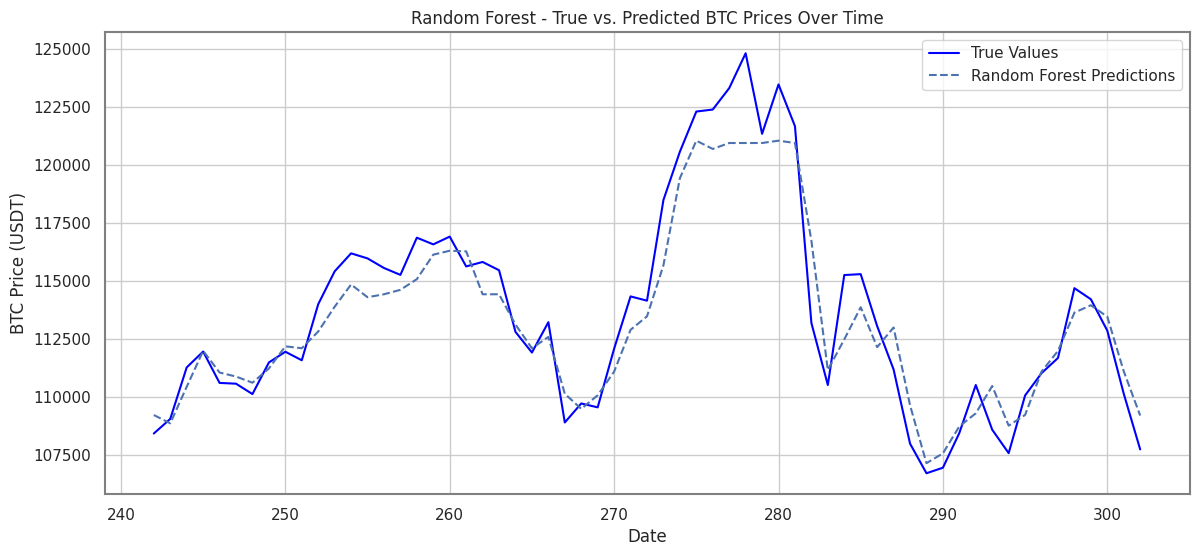

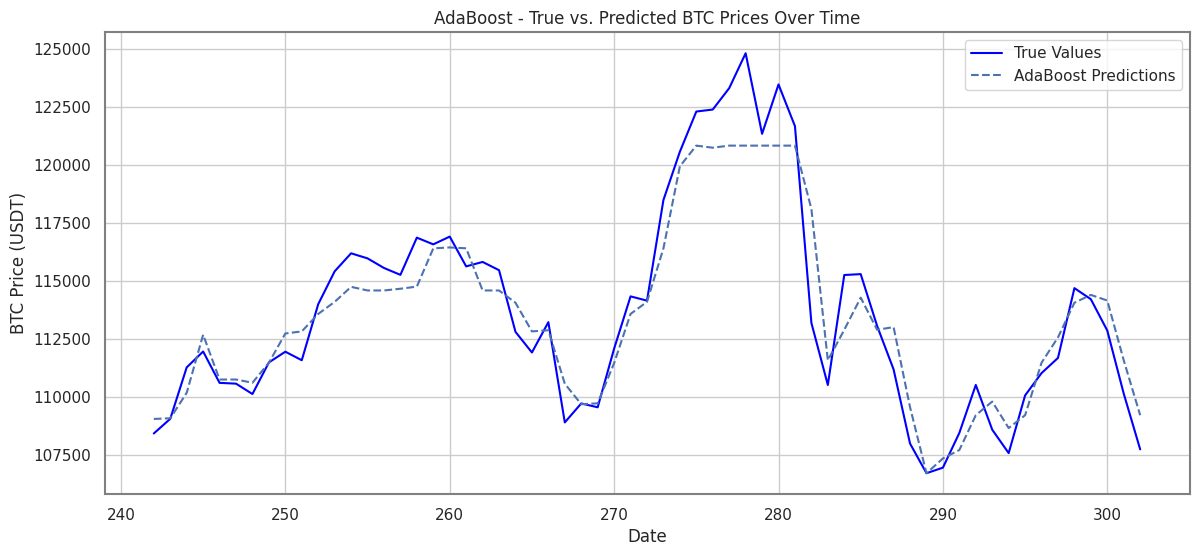

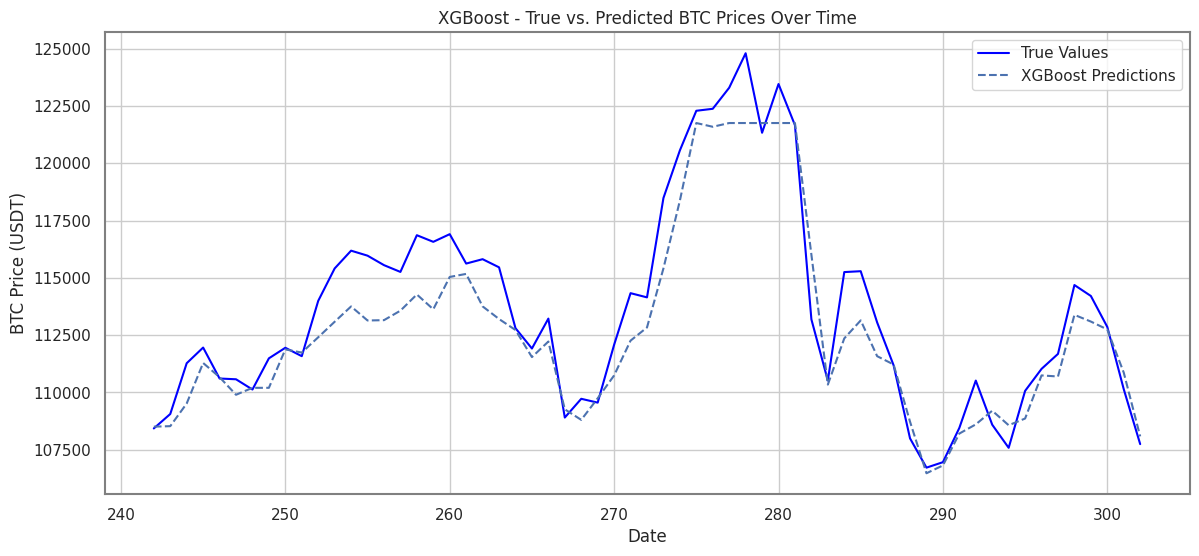

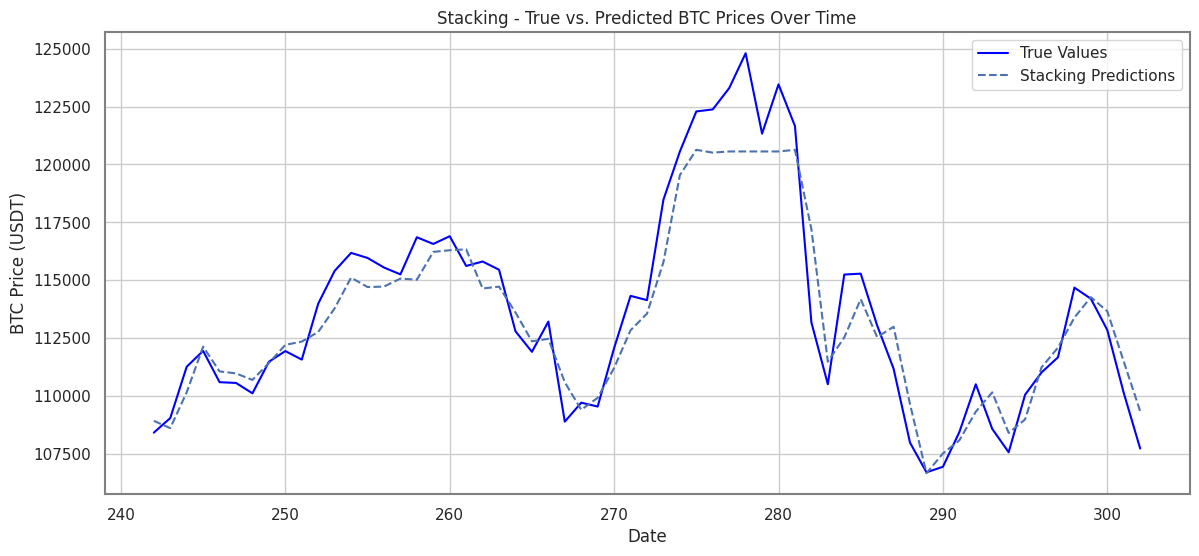

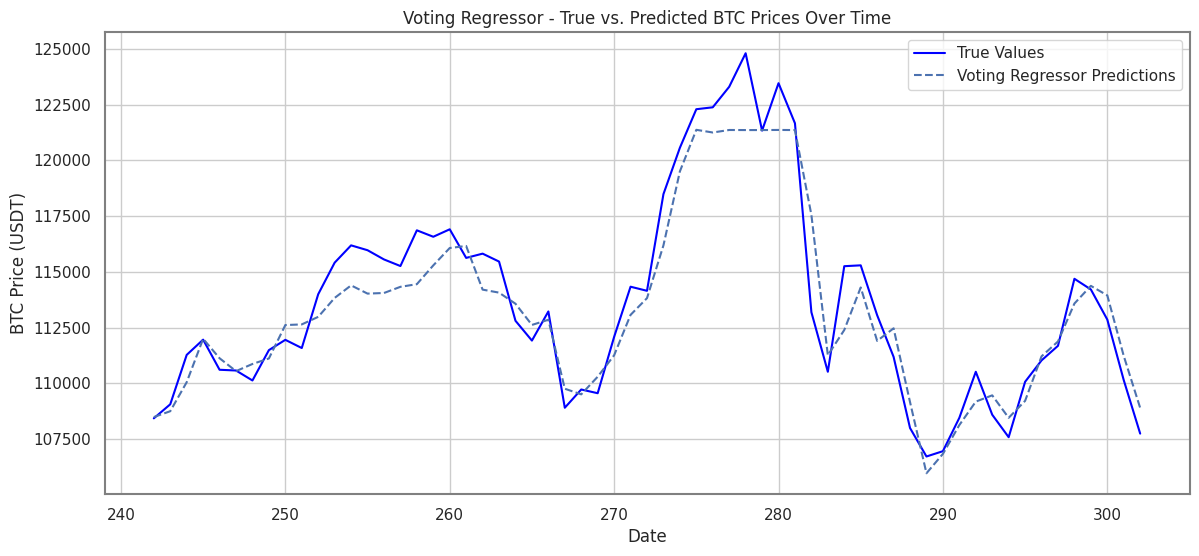

In [ ]:
# Import matplotlib.pyplot for creating visualizations and plots
import matplotlib.pyplot as plt


# Define a function to plot predictions vs true values for a given model
# Parameters:
#   - model_name: string name of the model being visualized (e.g., "Random Forest")
#   - predictions: array of predicted Close prices from the model
def plot_predictions(model_name, predictions):
    # Create a new figure with specified dimensions (14 inches wide by 6 inches tall)
    # This provides enough space to clearly see the time series data
    plt.figure(figsize=(14, 6))

    # Plot the true/actual BTC Close prices from the test set
    # X-axis: indices from X_test (representing dates)
    # Y-axis: actual Close prices from y_test
    # label: text for the legend identifying this line
    # color: blue line to distinguish from predictions
    plt.plot(X_test.index, y_test, label="True Values", color="blue")

    # Plot the model's predicted BTC Close prices on the same graph
    # X-axis: same indices from X_test to align with true values
    # Y-axis: predicted Close prices from the model
    # label: text for legend including the model name (e.g., "Random Forest Predictions")
    # linestyle: dashed line ("--") to visually distinguish from solid true values line
    plt.plot(
        X_test.index, predictions, label=f"{model_name} Predictions", linestyle="--"
    )

    # Set the title of the plot, including the model name dynamically
    # This helps identify which model's performance is being visualized
    plt.title(f"{model_name} - True vs. Predicted BTC Prices Over Time")

    # Label the x-axis to indicate it represents dates/time
    plt.xlabel("Date")

    # Label the y-axis to show it represents BTC price in USDT
    plt.ylabel("BTC Price (USDT)")

    # Display a legend showing which line represents true values vs predictions
    # Uses the labels defined in the plt.plot() calls above
    plt.legend()

    # Render and display the completed plot
    plt.show()


# Call the plot_predictions function for Random Forest model
# Uses the tuned/optimized Random Forest predictions (rf_pred_tuned)
plot_predictions("Random Forest", rf_pred_tuned)

# Call the plot_predictions function for AdaBoost model
# Uses the tuned/optimized AdaBoost predictions (ada_pred_tuned)
plot_predictions("AdaBoost", ada_pred_tuned)

# Call the plot_predictions function for XGBoost model
# Uses the tuned/optimized XGBoost predictions (xgb_pred_tuned)
plot_predictions("XGBoost", xgb_pred_tuned)

# Call the plot_predictions function for Stacking ensemble model
# Uses the tuned/optimized Stacking model predictions (stack_pred_tuned)
plot_predictions("Stacking", stack_pred_tuned)

# Call the plot_predictions function for Voting Regressor ensemble model
# Uses the Voting Regressor predictions (vote_pred)
# This model averages predictions from Random Forest, AdaBoost, and XGBoost
plot_predictions("Voting Regressor", vote_pred)

# Feature importance
Plot feature importance for Random Forest and XGBoost to see which inputs drive predictions.

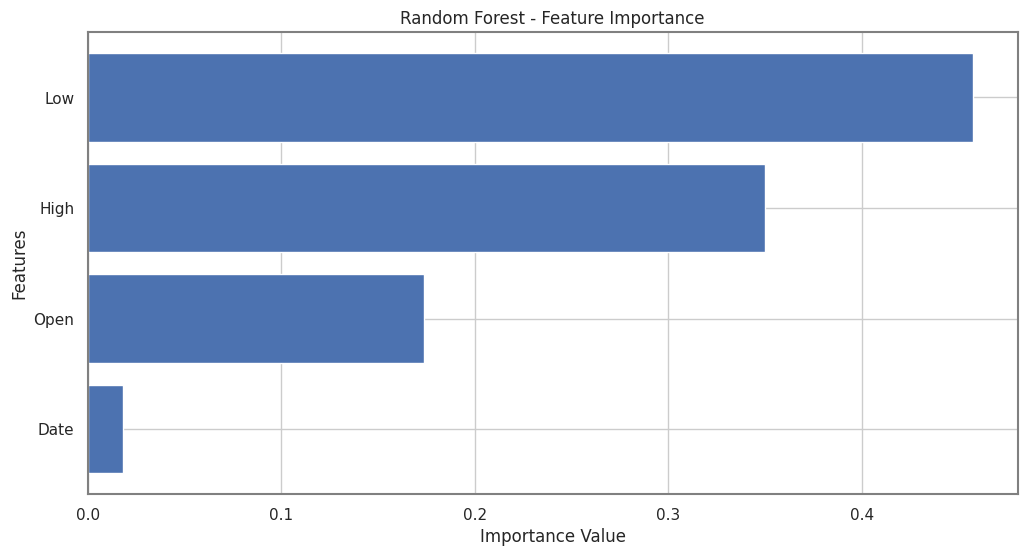

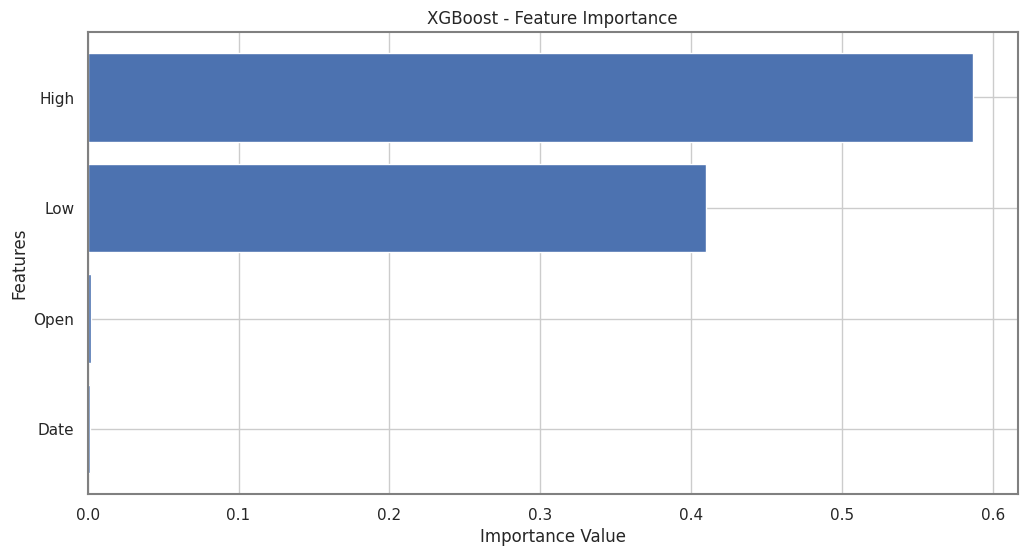

In [ ]:
def plot_feature_importance(importance, names, model_name):
    # Combine feature names and their importance values into a list of tuples
    feature_importance = list(zip(names, importance))
    # Sort the feature importance list by importance value in descending order
    sorted_feature_importance = sorted(
        feature_importance, key=lambda x: x[1], reverse=True
    )
    # Unpack the sorted feature names and their corresponding values
    names, vals = zip(*sorted_feature_importance)
    # Create a new figure for the plot with specified size
    plt.figure(figsize=(12, 6))
    # Plot a horizontal bar chart of feature importances
    plt.barh(names, vals, align="center")
    # Set the plot title to include the model name
    plt.title(model_name + " - Feature Importance")
    # Label the x-axis as "Importance Value"
    plt.xlabel("Importance Value")
    # Label the y-axis as "Features"
    plt.ylabel("Features")
    # Invert the y-axis so the most important feature appears at the top
    plt.gca().invert_yaxis()
    # Display the plot
    plt.show()


# Plot feature importances for the best Random Forest model
plot_feature_importance(best_rf.feature_importances_, X_train.columns, "Random Forest")
# Plot feature importances for the best XGBoost model
plot_feature_importance(best_xgb.feature_importances_, X_train.columns, "XGBoost")

# Error analysis: MAPE
Compute Mean Absolute Percentage Error (MAPE) for each model, visualize a comparison bar chart, and print the numeric values.

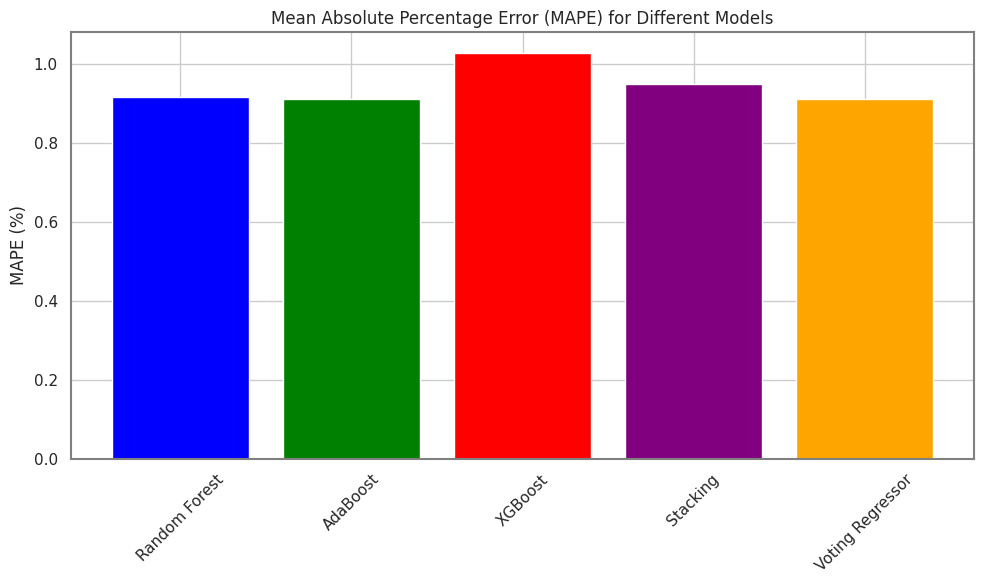

Random Forest MAPE: 0.92%
AdaBoost MAPE: 0.91%
XGBoost MAPE: 1.03%
Stacking MAPE: 0.95%
Voting Regressor MAPE: 0.91%


In [ ]:
import numpy as np  # Import numpy for numerical operations
import matplotlib.pyplot as plt  # Import matplotlib for plotting


def compute_mape(y_true, y_pred):
    # Guard against division by zero errors
    y_true, y_pred = np.array(y_true), np.array(
        y_pred
    )  # Convert inputs to numpy arrays
    valid_indices = y_true != 0  # Find indices where true values are not zero
    y_true = y_true[valid_indices]  # Filter out zero true values
    y_pred = y_pred[valid_indices]  # Filter corresponding predictions

    # Compute MAPE
    mape = 100 * np.mean(
        np.abs((y_true - y_pred) / y_true)
    )  # Calculate mean absolute percentage error
    return mape  # Return MAPE value


# Calculate MAPE for each model
mape_rf = compute_mape(y_test, rf_pred_tuned)  # MAPE for Random Forest
mape_ada = compute_mape(y_test, ada_pred_tuned)  # MAPE for AdaBoost
mape_xgb = compute_mape(y_test, xgb_pred_tuned)  # MAPE for XGBoost
mape_stack = compute_mape(y_test, stack_pred_tuned)  # MAPE for Stacking
mape_vote = compute_mape(y_test, vote_pred)  # MAPE for Voting Regressor

# Visualization
models = [
    "Random Forest",
    "AdaBoost",
    "XGBoost",
    "Stacking",
    "Voting Regressor",
]  # List of model names
mape_values = [
    mape_rf,
    mape_ada,
    mape_xgb,
    mape_stack,
    mape_vote,
]  # Corresponding MAPE values

plt.figure(figsize=(10, 6))  # Create a new figure with specified size
plt.bar(
    models, mape_values, color=["blue", "green", "red", "purple", "orange"]
)  # Plot bar chart of MAPE values
plt.ylabel("MAPE (%)")  # Set y-axis label
plt.title(
    "Mean Absolute Percentage Error (MAPE) for Different Models"
)  # Set plot title
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display the plot

# Print out the computed MAPE values
print(f"Random Forest MAPE: {mape_rf:.2f}%")  # Print MAPE for Random Forest
print(f"AdaBoost MAPE: {mape_ada:.2f}%")  # Print MAPE for AdaBoost
print(f"XGBoost MAPE: {mape_xgb:.2f}%")  # Print MAPE for XGBoost
print(f"Stacking MAPE: {mape_stack:.2f}%")  # Print MAPE for Stacking
print(f"Voting Regressor MAPE: {mape_vote:.2f}%")  # Print MAPE for Voting Regressor

# Next-day prediction (Random Forest)
Build the feature row for the last available day, predict the next-day Close with the best RF model, and print predicted vs actual.

In [ ]:
# Select the last row from the btc_usdt DataFrame (represents the next day to predict)
next_day_row = btc_usdt.iloc[-1:]

# Remove the 'Close' column from the selected row to create the feature set for prediction
next_day_data = next_day_row.drop(columns=["Close"])

# Extract the timestamp from the selected row, convert it to a readable date string (YYYY-MM-DD)
next_day_date = pd.to_datetime(next_day_row.iloc[0, 0], unit="ms").strftime("%Y-%m-%d")

# Use the trained Random Forest model to predict the closing price for the selected day
next_day_pred_rf = best_rf.predict(next_day_data)

# Print the date for which the prediction is made
print(f"Predictions for {next_day_date}:")

# Print the predicted closing price and the actual closing price for comparison
print(
    f"Random Forest BTC-USD Closing: {next_day_pred_rf[0]} USDT and True value is {next_day_row['Close'].values[0]} USDT"
)

Predictions for 2025-10-30:
Random Forest BTC-USD Closing: 109205.14980662335 USDT and True value is 107747.93 USDT


In [ ]:
import requests  # For making HTTP requests to APIs
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
from datetime import datetime, timedelta  # For handling dates and times
import warnings  # For managing warning messages
#import streamlit as st
from sklearn.model_selection import train_test_split  # For splitting data

warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

# Define the Binance API endpoint for daily BTC/USDT candlestick data
#key = "https://api.binance.us/api/v3/klines?symbol=BTCUSDT&interval=1d&startTime=1735689600000"
# key="https://api.coingecko.com/api/v3/coins/bitcoin/ohlc"
# req={"vs_currency":"usd","days":"365"}
key="https://api.huobi.pro/market/history/kline"
req={"symbol":"btcusdt","period":"1day","size":"365"}
# Send a GET request to the API endpoint
data = requests.get(key,req)
data = data.json()  # Parse the response as JSON
#prices =  data["data"]
data

{'ts': 1764005271027,
 'status': 'error',
 'err-code': 'invalid-parameter',
 'err-msg': 'invalid symbol'}

In [ ]:

prices["id"]=pd.Timestamp(prices["id"])
# Convert the list of price dictionaries into a pandas DataFrame
btc_usdt = pd.DataFrame(prices)
# st.dataframe(btc_usdt)
btc_usdt.set_index("Date", inplace=True)  # Set 'Date' as the index
# st.warning(f"Loaded data shape: {btc_usdt.shape}")
# st.dataframe(btc_usdt.head())

# st.divider()
# Ensure we have all the necessary columns and handle any missing values
btc_usdt = btc_usdt.fillna(method="ffill")  # Forward fill missing values

# st.write("\nColumns in dataset:", list(btc_usdt.columns))  # Print column names

btc_usdt